# סימולציה של תגובה אנזימטית בעזרת SciPy

במחברת זו נשתמש ב־**SciPy** כדי לפתור משוואות דיפרנציאליות שמתארות תגובה כימית. הדוגמה תהיה מינימלית, אבל לא כזו שנפתור בקלות ביד: מנגנון אנזימטי פשוט עם יצירת קומפלקס ביניים.

הרעיון החשוב הוא שאם אנחנו יודעים את חוקי השינוי הרגעיים, **SciPy** יכולה לחשב עבורנו את ההתפתחות בזמן.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## המנגנון

נשתמש במנגנון אנזימטי בסיסי:

$$E + S \rightleftharpoons ES \rightarrow E + P$$

כאן $E$ הוא האנזים החופשי, $S$ הוא הסובסטרט, $ES$ הוא קומפלקס אנזים־סובסטרט, ו־$P$ הוא התוצר. המנגנון קצר, אבל כבר כולל כמה ריכוזים שמשפיעים זה על זה.

נסמן את קבועי הקצב כך:

$$
E + S \xrightarrow{k_1} ES
$$

$$
ES \xrightarrow{k_{-1}} E + S
$$

$$
ES \xrightarrow{k_\mathrm{cat}} E + P
$$

### בעיית התחלה: קינטיקה אנזימטית

נראה כיצד עושים זאת מעשית. כדי לחשב איך הריכוזים משתנים בזמן, נגדיר וקטור שמכיל את כל הריכוזים. בקוד נשתמש באותו סדר לאורך כל המחברת:

$$
\mathbf{y}(t) =
\begin{pmatrix}
[S](t) \\
[E](t) \\
[ES](t) \\
[P](t)
\end{pmatrix}
$$

נשתמש בפונקציה `solve_ivp` של **SciPy**. השם הוא קיצור של "solve initial value problem": פתרון של משוואות דיפרנציאליות כאשר ידוע מצב ההתחלה. צריך לתת לה שלושה דברים עיקריים: פונקציה שמחשבת את הנגזרות, תחום זמן, ותנאי התחלה.

נתחיל עם השניים האחרונים:


In [6]:
S0 = 1.0   # mmol/L
E0 = 0.08  # mmol/L
ES0 = 0.0
P0 = 0.0

y0 = [S0, E0, ES0, P0]

time_span = (0, 20)
t_eval = np.linspace(time_span[0], time_span[1], 300)

כעת צריך להגדיר את הפונקציה שמחזירה את הקצב שבו כל ריכוז משתנה:

$$
\frac{d\mathbf{y}}{dt} = f(t,\mathbf{y})
$$

במקרה שלנו, לפי חוק הפעולה ההמונית:

$$
\frac{d[S]}{dt} = -k_1[E][S] + k_{-1}[ES]
$$

$$
\frac{d[E]}{dt} = -k_1[E][S] + k_{-1}[ES] + k_\mathrm{cat}[ES]
$$

$$
\frac{d[ES]}{dt} = k_1[E][S] - k_{-1}[ES] - k_\mathrm{cat}[ES]
$$

$$
\frac{d[P]}{dt} = k_\mathrm{cat}[ES]
$$

האיבר $[E][S]$ הופך את הבעיה ללא־ליניארית, ולכן זו דוגמה טובה למצב שבו פתרון נומרי באמת שימושי.

נגדיר את הפונקציה בקוד:


In [7]:
k1 = 8.0      # 1/(mmol/L min)
km1 = 1.0     # 1/min
kcat = 0.7    # 1/min

def enzyme_rhs(t, y):
    S, E, ES, P = y
    binding = k1 * E * S
    unbinding = km1 * ES
    reaction = kcat * ES

    dSdt = -binding + unbinding
    dEdt = -binding + unbinding + reaction
    dESdt = binding - unbinding - reaction
    dPdt = reaction

    return [dSdt, dEdt, dESdt, dPdt]

כעת אפשר למצוא את הפתרון. בקריאה הבאה נעביר ל־`solve_ivp` את הפונקציה שמחשבת את קצבי השינוי (`enzyme_rhs`), את תחום הזמן (`time_span`), ואת תנאי ההתחלה (`y0`). הפרמטר `t_eval` אומר ל־SciPy באילו נקודות זמן להחזיר לנו את הפתרון.


In [8]:
solution = solve_ivp(enzyme_rhs, time_span, y0, t_eval=t_eval)
print(solution.success)
print(solution.message)

True
The solver successfully reached the end of the integration interval.


האובייקט `solution` מכיל את הזמנים ואת הריכוזים שחושבו. נפריד אותם למשתנים עם שמות נוחים יותר.

In [9]:
t = solution.t
S, E, ES, P = solution.y

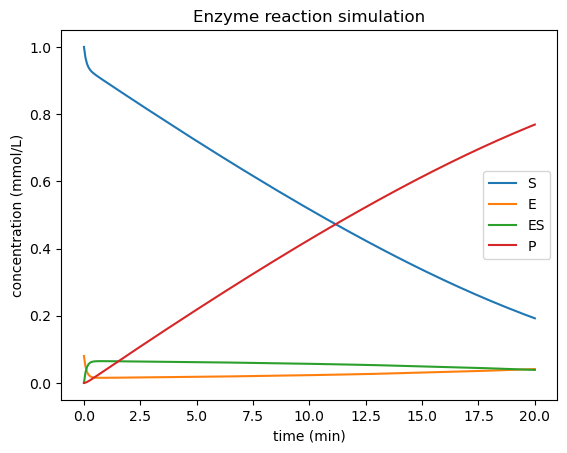

In [10]:
plt.figure()
plt.plot(t, S, label='S')
plt.plot(t, E, label='E')
plt.plot(t, ES, label='ES')
plt.plot(t, P, label='P')
plt.xlabel('time (min)')
plt.ylabel('concentration (mmol/L)')
plt.title('Enzyme reaction simulation')
plt.legend()
plt.show()

אפשר לראות כי הקומפלקס $ES$ נוצר מהר יחסית ואז משתנה לאט יותר. התוצר $P$ הולך וגדל, והסובסטרט $S$ הולך ונצרך.

## בדיקת שימור חומר

סימולציה טובה צריכה גם לעבור בדיקות פשוטות ולקיים חוקי שימור. כאן כמות האנזים הכוללת אמורה להישמר:

$$[E] + [ES] = \mathrm{constant}$$

בנוסף, כמות החומר שמקורו בסובסטרט אמורה להישמר:

$$[S] + [ES] + [P] = \mathrm{constant}$$

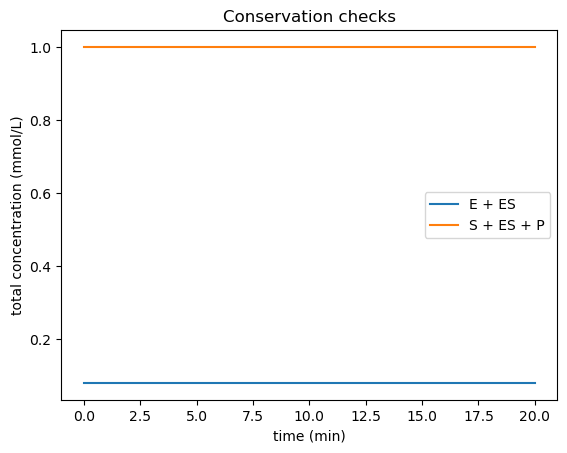

enzyme total at start = 0.080000
enzyme total at end   = 0.080000
substrate total at start = 1.000000
substrate total at end   = 1.000000


In [12]:
enzyme_total = E + ES
substrate_total = S + ES + P

plt.figure()
plt.plot(t, enzyme_total, label='E + ES')
plt.plot(t, substrate_total, label='S + ES + P')
plt.xlabel('time (min)')
plt.ylabel('total concentration (mmol/L)')
plt.title('Conservation checks')
plt.legend()
plt.show()

print(f'enzyme total at start = {enzyme_total[0]:.6f}')
print(f'enzyme total at end   = {enzyme_total[-1]:.6f}')
print(f'substrate total at start = {substrate_total[0]:.6f}')
print(f'substrate total at end   = {substrate_total[-1]:.6f}')

## מה קורה אם משנים את כמות האנזים?

עכשיו נריץ את אותה סימולציה עבור כמה ריכוזי אנזים התחלתיים. הפעם נציג רק את התוצר, כדי שהגרף יישאר קריא.

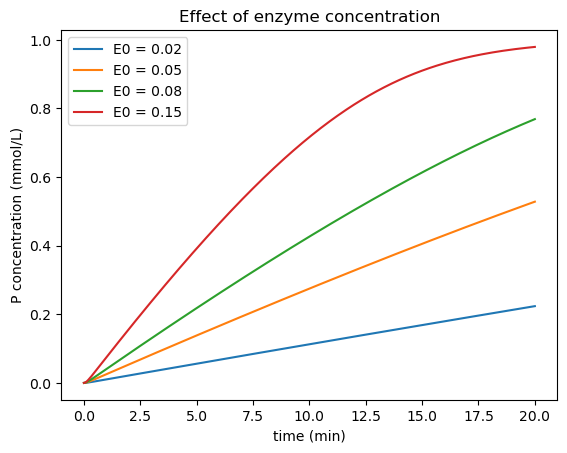

In [13]:
enzyme_initial_values = [0.02, 0.05, 0.08, 0.15]

plt.figure()
for E0 in enzyme_initial_values:
    y0 = [S0, E0, 0.0, 0.0]
    solution = solve_ivp(enzyme_rhs, time_span, y0, t_eval=t_eval)
    P = solution.y[3]
    plt.plot(solution.t, P, label=f'E0 = {E0}')

plt.xlabel('time (min)')
plt.ylabel('P concentration (mmol/L)')
plt.title('Effect of enzyme concentration')
plt.legend()
plt.show()

הכיוון הכללי ברור מהתוצאה: יותר אנזים יוצר תוצר מהר יותר. עם זאת, הצורה המדויקת של העקומות התקבלה כאן מחישוב נומרי, לא מהצבה בנוסחה אנליטית. זה אפשרי במספר עצום של סיטואציות שבהן אי אפשר לפתור אנליטית את המשוואות.

## תרגילים קצרים

1. שנו את $k_\mathrm{cat}$ ובדקו איך משתנה קצב יצירת התוצר.
2. שנו את $k_1$ ובדקו האם הקומפלקס $ES$ נוצר מהר יותר.
3. נסו להקטין את ריכוז האנזים פי עשרה. האם עדיין מקבלים כמעט את כל התוצר תוך 20 דקות?
4. הוסיפו גרף שמציג רק את $ES$ עבור כמה ערכי $k_1$.